# IPL Score Prediction

Predict a first-innings final total from the current match state. This is a beginner regression project: the model sees an innings snapshot and estimates the `total` column.

**You will learn:** categorical features, match-level splitting, neural-network regression, MAE, and a simple prediction function.

All code, explanations, and data used by this project are included in this repository.


## 1. Import libraries and fix the random seed

Pandas handles the match table, scikit-learn prepares features, and TensorFlow trains the regressor. A fixed seed makes the split and model initialization repeatable.


In [1]:
from pathlib import Path
import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

pd.set_option("display.max_columns", 30)
print("TensorFlow:", tf.__version__)


TensorFlow: 2.21.0


## 2. Load the ball-by-ball dataset

The local CSV contains first-innings delivery states and the final innings total used as the target.


In [2]:
DATA_PATH = Path("data/ipl_matches.csv") if Path("data/ipl_matches.csv").exists() else Path("../data/ipl_matches.csv")
if not DATA_PATH.exists():
    raise FileNotFoundError("Run this notebook from the repository root so data/ is available.")

ipl = pd.read_csv(DATA_PATH)
required_columns = {
    "mid", "venue", "bat_team", "bowl_team", "runs", "wickets", "overs",
    "runs_last_5", "wickets_last_5", "total",
}
missing = required_columns.difference(ipl.columns)
if missing:
    raise ValueError(f"Dataset schema changed; missing: {sorted(missing)}")

ipl = ipl.dropna(subset=required_columns).copy()
print("Rows:", len(ipl))
print("Matches:", ipl["mid"].nunique())
ipl.head()

Rows: 76014
Matches: 617


,mid,date,venue,bat_team,bowl_team,batsman,bowler,runs,wickets,overs,runs_last_5,wickets_last_5,striker,non-striker,total
0,1,2008-04-18,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,SC Ganguly,P Kumar,1,0,0.1,1,0,0,0,222
1,1,2008-04-18,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,P Kumar,1,0,0.2,1,0,0,0,222
2,1,2008-04-18,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,P Kumar,2,0,0.2,2,0,0,0,222
3,1,2008-04-18,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,P Kumar,2,0,0.3,2,0,0,0,222
4,1,2008-04-18,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,P Kumar,2,0,0.4,2,0,0,0,222


## 3. Inspect what we are trying to predict

One final total belongs to each match. This plot shows the range of historical first-innings scores before we train a model.


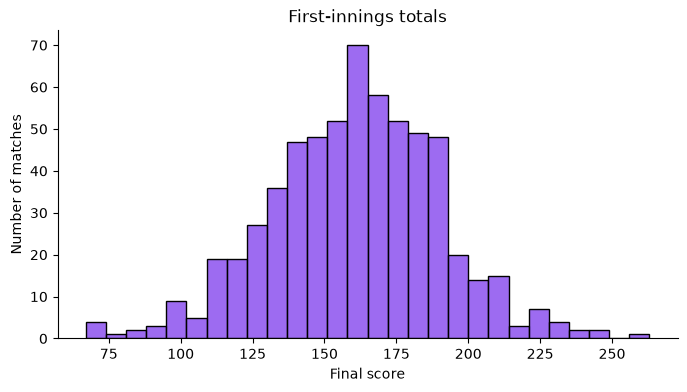

count    617.0
mean     160.3
std       29.7
min       67.0
25%      141.0
50%      161.0
75%      181.0
max      263.0
Name: total, dtype: float64

In [3]:
match_totals = ipl[["mid", "total"]].drop_duplicates("mid")

fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(match_totals["total"], bins=28, color="#7C3AED", ax=ax)
ax.set(title="First-innings totals", xlabel="Final score", ylabel="Number of matches")
ax.spines[["top", "right"]].set_visible(False)
plt.show()

match_totals["total"].describe().round(1)


## 4. Split by match, then prepare the columns

Many rows belong to the same match. A random row split would put one match in both training and test data, so we hold out entire match IDs instead. The preprocessor learns scaling and team/venue categories from the training matches only.


In [4]:
numeric_features = ["runs", "wickets", "overs", "runs_last_5", "wickets_last_5"]
categorical_features = ["bat_team", "bowl_team", "venue"]
feature_columns = numeric_features + categorical_features

train_match_ids, test_match_ids = train_test_split(
    ipl["mid"].unique(), test_size=0.20, random_state=SEED
)
train_frame = ipl[ipl["mid"].isin(train_match_ids)].copy()
test_frame = ipl[ipl["mid"].isin(test_match_ids)].copy()

preprocessor = ColumnTransformer(
    transformers=[
        ("numbers", StandardScaler(), numeric_features),
        ("categories", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_features),
    ],
    remainder="drop",
)

X_train = preprocessor.fit_transform(train_frame[feature_columns]).astype("float32")
X_test = preprocessor.transform(test_frame[feature_columns]).astype("float32")
y_train = train_frame["total"].to_numpy(dtype="float32")
y_test = test_frame["total"].to_numpy(dtype="float32")

print("Training rows:", X_train.shape, "from", len(train_match_ids), "matches")
print("Test rows:    ", X_test.shape, "from", len(test_match_ids), "matches")


Training rows: (60782, 68) from 493 matches
Test rows:     (15232, 68) from 124 matches


## 5. Build the regression network

The output is one number, not a class, so the last layer uses a linear activation. Huber loss is less sensitive to an unusually high or low score than plain squared error.


In [5]:
model = tf.keras.Sequential(
    [
        tf.keras.layers.Input(shape=(X_train.shape[1],)),
        tf.keras.layers.Dense(96, activation="relu"),
        tf.keras.layers.Dropout(0.15),
        tf.keras.layers.Dense(32, activation="relu"),
        tf.keras.layers.Dense(1),
    ],
    name="ipl_score_regressor",
)
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss=tf.keras.losses.Huber(),
    metrics=[tf.keras.metrics.MeanAbsoluteError(name="mae")],
)
model.summary()


Model: "ipl_score_regressor"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 96)             │         6,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 96)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,761 (38.13 KB)

 Trainable params: 9,761 (38.13 KB)

 Non-trainable params: 0 (0.00 B)

## 6. Train the model

Early stopping keeps the demo quick and restores the best validation weights. Increase `EPOCHS` later only after you understand the baseline.


In [6]:
EPOCHS = 15
history = model.fit(
    X_train,
    y_train,
    validation_split=0.15,
    epochs=EPOCHS,
    batch_size=256,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss", patience=3, restore_best_weights=True
        )
    ],
    verbose=2,
)


Epoch 1/15


202/202 - 1s - 2ms/step - loss: 94.4445 - mae: 94.9430 - val_loss: 24.4793 - val_mae: 24.9762


Epoch 2/15


202/202 - 0s - 518us/step - loss: 17.1412 - mae: 17.6351 - val_loss: 22.8870 - val_mae: 23.3824


Epoch 3/15


...

202/202 - 0s - 511us/step - loss: 15.1813 - mae: 15.6735 - val_loss: 22.1305 - val_mae: 22.6264


Epoch 7/15


202/202 - 0s - 510us/step - loss: 15.0620 - mae: 15.5542 - val_loss: 22.3098 - val_mae: 22.8044


Epoch 8/15


202/202 - 0s - 507us/step - loss: 14.8714 - mae: 15.3637 - val_loss: 22.7461 - val_mae: 23.2418


## 7. Check the learning curves

Train and validation loss should generally fall together. A widening gap suggests the model is starting to memorize training examples.


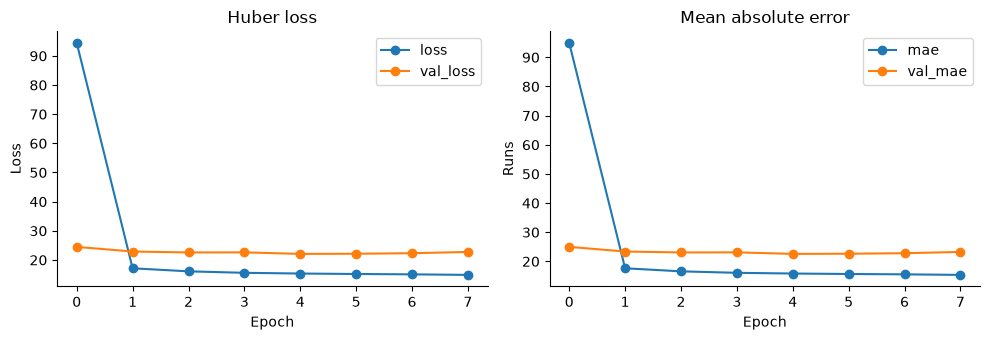

In [7]:
history_frame = pd.DataFrame(history.history)
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))

history_frame[["loss", "val_loss"]].plot(ax=axes[0], marker="o")
axes[0].set(title="Huber loss", xlabel="Epoch", ylabel="Loss")

history_frame[["mae", "val_mae"]].plot(ax=axes[1], marker="o")
axes[1].set(title="Mean absolute error", xlabel="Epoch", ylabel="Runs")

for ax in axes:
    ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()


## 8. Evaluate on unseen matches

MAE is the easiest metric to explain here: on average, how many runs away is the estimate? The scatter plot also reveals where the model tends to over- or under-predict.


Test MAE:  16.3 runs
Test RMSE: 21.9 runs
Test R²:   0.375


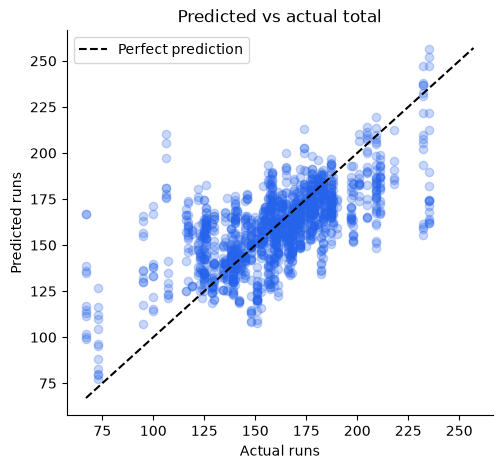

In [8]:
predictions = model.predict(X_test, verbose=0).ravel()
mae = mean_absolute_error(y_test, predictions)
rmse = mean_squared_error(y_test, predictions) ** 0.5
r2 = r2_score(y_test, predictions)
print(f"Test MAE:  {mae:.1f} runs")
print(f"Test RMSE: {rmse:.1f} runs")
print(f"Test R²:   {r2:.3f}")

sample = np.random.default_rng(SEED).choice(len(y_test), size=min(1500, len(y_test)), replace=False)
fig, ax = plt.subplots(figsize=(5.5, 5))
ax.scatter(y_test[sample], predictions[sample], alpha=0.25, color="#2563EB")
limits = [min(y_test.min(), predictions.min()), max(y_test.max(), predictions.max())]
ax.plot(limits, limits, "--", color="black", label="Perfect prediction")
ax.set(title="Predicted vs actual total", xlabel="Actual runs", ylabel="Predicted runs")
ax.legend()
ax.spines[["top", "right"]].set_visible(False)
plt.show()


## 9. Predict one innings snapshot

This helper applies the same fitted preprocessor before asking the neural network for a final-score estimate. The example comes from a held-out match.


In [9]:
def predict_final_score(match_state: dict) -> float:
    row = pd.DataFrame([match_state], columns=feature_columns)
    encoded = preprocessor.transform(row).astype("float32")
    return float(model.predict(encoded, verbose=0)[0, 0])

example_row = test_frame.sample(n=1, random_state=SEED).iloc[0]
example_state = example_row[feature_columns].to_dict()
estimate = predict_final_score(example_state)

print("Current state:", example_state)
print(f"Predicted final score: {estimate:.0f}")
print(f"Actual final score:    {example_row['total']:.0f}")


Current state: {'runs': 86, 'wickets': 4, 'overs': 14.4, 'runs_last_5': 29, 'wickets_last_5': 2, 'bat_team': 'Kings XI Punjab', 'bowl_team': 'Kolkata Knight Riders', 'venue': 'Eden Gardens'}
Predicted final score: 132
Actual final score:    134


## Try next

Add batter and bowler features, compare this network with linear regression, or predict a score range instead of one number. Remember: historical predictions are not betting advice.
